# **Traction Force Microscopy Dataset**

In [3]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import os

In [4]:
dataset_path = "/kaggle/input/traction-force-microscopy-dataset"
all_data = {}

folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])[:15]

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    
    images = [tiff.imread(os.path.join(folder_path, f)) 
              for f in sorted(os.listdir(folder_path)) if f.endswith(".tif")]
    images = np.array(images)
    
    # Remove NaN if exist
    images = np.nan_to_num(images, nan=0.0)
    
    # Normalize per-folder
    images = (images - images.min()) / (images.max() - images.min() + 1e-8)
    
    all_data[folder] = images
    print(f"Loaded {folder} → shape {images.shape}")

Loaded 20160809-002-xy1FORCE → shape (181, 1060, 1056)
Loaded 20160809-002-xy1FRET → shape (181, 1060, 1056)
Loaded 20160809-002-xy1RAW → shape (181, 1060, 1056)
Loaded 20160809-002-xy2FORCE → shape (181, 1060, 1056)
Loaded 20160809-002-xy2FRET → shape (181, 1060, 1056)
Loaded 20160809-002-xy2RAW → shape (181, 1060, 1056)
Loaded 20160809-002-xy3FORCE → shape (181, 1060, 1040)
Loaded 20160809-002-xy3FRET → shape (181, 1060, 1040)
Loaded 20160809-002-xy3RAW → shape (181, 1060, 1040)
Loaded 20160809-002-xy4FORCE → shape (181, 1060, 1058)
Loaded 20160809-002-xy4FRET → shape (181, 1060, 1058)
Loaded 20160809-002-xy4RAW → shape (181, 1060, 1058)
Loaded 20160809-002-xy5FORCE → shape (181, 1048, 1036)
Loaded 20160809-002-xy5FRET → shape (181, 1048, 1036)
Loaded 20160809-002-xy5RAW → shape (181, 1048, 1036)


**Show example frames per type (FORCE, FRET, RAW)**

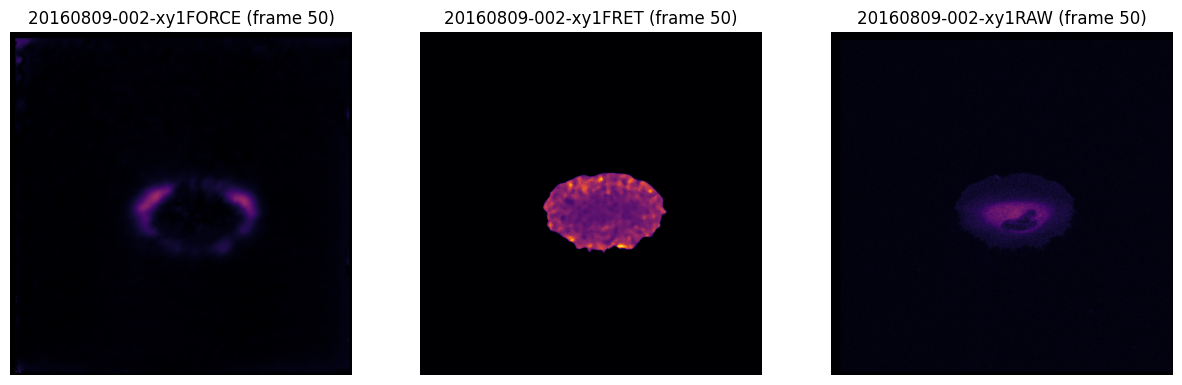

In [6]:
folder = list(all_data.keys())[0]
images = all_data[folder]

time_idx = 50 

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, modality in enumerate(["FORCE", "FRET", "RAW"]):
    for f in all_data.keys():
        if modality in f:
            img = all_data[f][time_idx]
            axs[i].imshow(img, cmap="inferno")
            axs[i].set_title(f"{f} (frame {time_idx})")
            axs[i].axis("off")
            break
plt.show()

**Plot intensity distribution (histogram)**

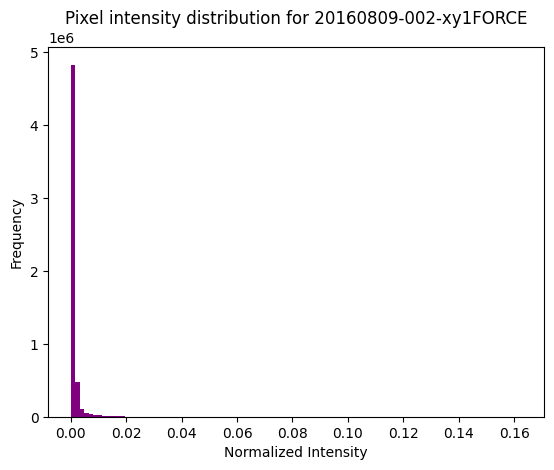

In [ ]:
folder = list(all_data.keys())[0]
images = all_data[folder]

pixels = images[:5].ravel()

plt.hist(pixels, bins=100, color="purple")
plt.title(f"Pixel intensity distribution for {folder}")
plt.xlabel("Normalized Intensity")
plt.ylabel("Frequency")
plt.show()

**Mean image over time**

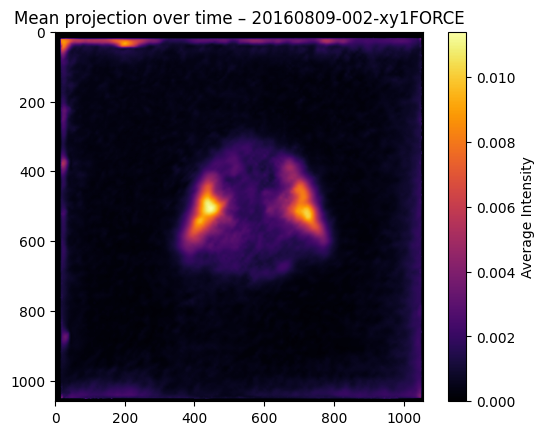

In [8]:
mean_img = images.mean(axis=0)

plt.imshow(mean_img, cmap="inferno")
plt.title(f"Mean projection over time – {folder}")
plt.colorbar(label="Average Intensity")
plt.show()

**Temporal dynamics (mean intensity per frame)**

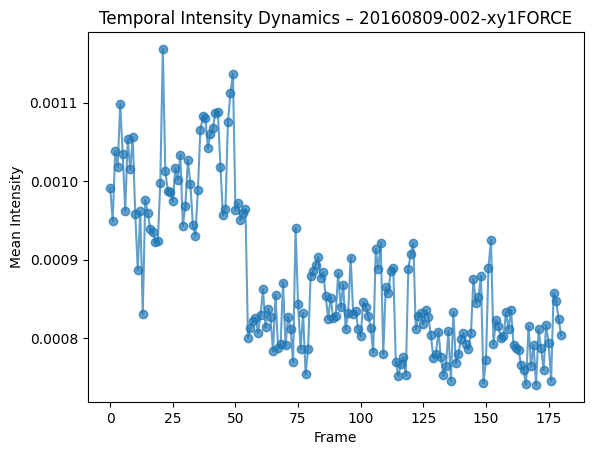

In [ ]:
mean_intensity = images.mean(axis=(1,2)) 

plt.plot(mean_intensity, marker="o", alpha=0.7)
plt.title(f"Temporal Intensity Dynamics – {folder}")
plt.xlabel("Frame")
plt.ylabel("Mean Intensity")
plt.show()

**Side-by-side FORCE vs FRET**

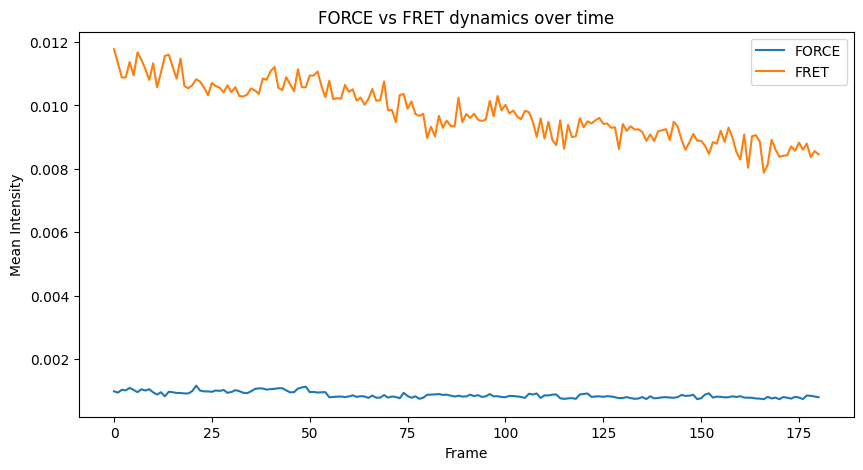

In [10]:
force_folder = [f for f in all_data if "FORCE" in f][0]
fret_folder  = [f for f in all_data if "FRET" in f][0]

force_intensity = all_data[force_folder].mean(axis=(1,2))
fret_intensity  = all_data[fret_folder].mean(axis=(1,2))

plt.figure(figsize=(10,5))
plt.plot(force_intensity, label="FORCE")
plt.plot(fret_intensity, label="FRET")
plt.title("FORCE vs FRET dynamics over time")
plt.xlabel("Frame")
plt.ylabel("Mean Intensity")
plt.legend()
plt.show()

**Variability heatmap**

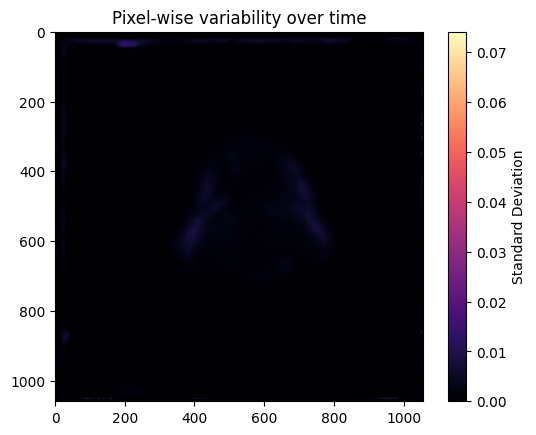

In [11]:
std_img = images.std(axis=0)
plt.imshow(std_img, cmap="magma")
plt.title("Pixel-wise variability over time")
plt.colorbar(label="Standard Deviation")
plt.show()